In [10]:
# 1 - Read CSV files

import pandas as pd

food = pd.read_csv('61111-0004_de.csv', usecols=[0,1,4], 
names=['Year', 'Month', 'Index'], skiprows=83, nrows=204, sep=';', decimal=',')   
gold = pd.read_csv('A0S9GB Historische Daten.csv', usecols=[0,2], sep=',', decimal=',')


In [11]:
# 2 - Edit Tables 

food['Year'] = food['Year'].ffill().apply(int) # add year to NaN and make to int
# Create a dictionary to map German month names to numbers
month_dict = {
    'Januar': 1, 'Februar': 2, 'März': 3, 'April': 4, 'Mai': 5, 'Juni': 6, 'Juli': 7, 'August': 8, 
    'September': 9, 'Oktober': 10, 'November': 11, 'Dezember': 12
}

# Convert German month names to numeric month values
food['MonthNum'] = food['Month'].map(month_dict)

# Create a Date column
food['Date'] = pd.to_datetime(food['Year'].astype(str) + '-' + food['MonthNum'].astype(str) + '-01')

# Drop temporary MonthNum column if not needed
food = food.drop('MonthNum', axis=1)

food = food[['Date', 'Year', 'Month', 'Index']]


# Formating the golds Date: Seperate columns for "Year" and "Month"
gold['Datum'] = pd.to_datetime(gold['Datum'], format='%d.%m.%Y')
gold['Year'] = gold['Datum'].dt.year
gold['Month'] = gold['Datum'].dt.month_name(locale='de_DE.UTF-8') 


# Ascending order: Start table at 2002 instead of 2024
gold = gold.iloc[::-1].reset_index(drop=True) 

# Change column names and order
gold.columns = ['Date', 'Price', 'Year', 'Month']
gold = gold[['Date', 'Year', 'Month', 'Price']] 


print('Food Head: \n', food.head(), '\n')
print('Gold head (Bei Gold fehlt die Normalisierung): \n', gold.head(), '\n') 


Food Head: 
         Date  Year    Month  Index
0 2008-01-01  2008   Januar   80.3
1 2008-02-01  2008  Februar   80.3
2 2008-03-01  2008     März   80.7
3 2008-04-01  2008    April   81.0
4 2008-05-01  2008      Mai   81.0 

Gold head (Bei Gold fehlt die Normalisierung): 
         Date  Year    Month  Price
0 2008-01-01  2008   Januar  18.43
1 2008-02-01  2008  Februar  20.40
2 2008-03-01  2008     März  20.80
3 2008-04-01  2008    April  18.66
4 2008-05-01  2008      Mai  17.75 



In [12]:
# 3 - Normalize data for the year 2020

# food is already normalized 
# Only need to create the normalization for gold
gold_2020 = gold[gold['Year'] == 2020]
gold_mean_2020 = gold_2020['Price'].mean()
gold['Index'] = ((gold['Price'] / gold_mean_2020) * 100).round(2)
# change order to match food
gold = gold[['Date', 'Year', 'Month', 'Index', 'Price']]

print('Food war bereits normalisiert \n', food.head())
print('Gold normalisiert: \n', gold.head())


Food war bereits normalisiert 
         Date  Year    Month  Index
0 2008-01-01  2008   Januar   80.3
1 2008-02-01  2008  Februar   80.3
2 2008-03-01  2008     März   80.7
3 2008-04-01  2008    April   81.0
4 2008-05-01  2008      Mai   81.0
Gold normalisiert: 
         Date  Year    Month  Index  Price
0 2008-01-01  2008   Januar  37.24  18.43
1 2008-02-01  2008  Februar  41.23  20.40
2 2008-03-01  2008     März  42.03  20.80
3 2008-04-01  2008    April  37.71  18.66
4 2008-05-01  2008      Mai  35.87  17.75


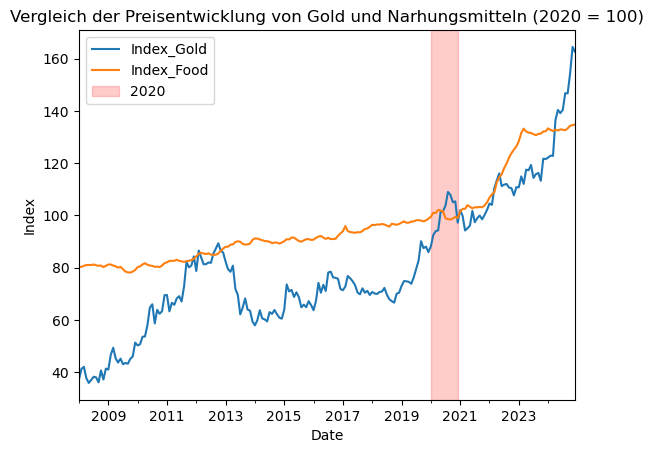

In [13]:
# 4- Algorithm
  # 1 - "Liniendiagramm-Vergleich der Preisentwicklung von Gold und Narhungsmitteln (2020 = 100)""

from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# Set Date as index for both DataFrames
gold = gold.set_index('Date')
food = food.set_index('Date')

# Merge the data
merged = gold[['Index']].merge(food[['Index']], left_index=True, right_index=True, suffixes=('_Gold', '_Food'))


# Plot both indices over time
merged.plot(title='Vergleich der Preisentwicklung von Gold und Narhungsmitteln (2020 = 100)', ylabel='Index')
# Add a vertical span for the entire year 2020
plt.axvspan(pd.to_datetime('2020-01-01'), pd.to_datetime('2020-12-01'), color='red', alpha=0.2, label='2020')

plt.legend()
plt.show()


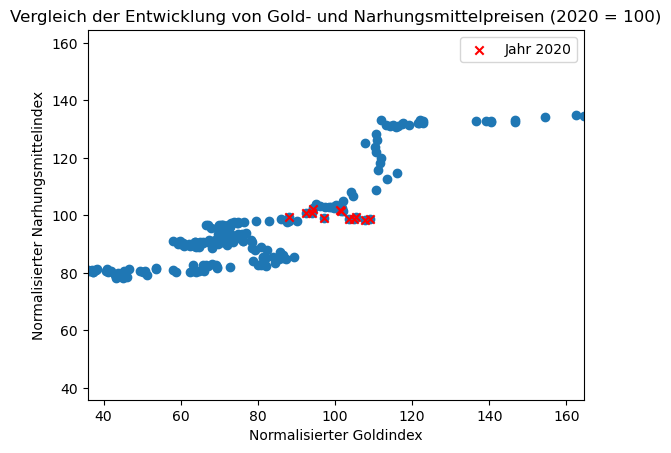

In [14]:
# 4 - Algorithm
    # 2 - "Streudiagramm-Vergleich der Entwicklung von Gold- und Lebensmittelpreisen (2020 = 100)"

# Scatter plot for all data
plt.scatter(merged['Index_Gold'], merged['Index_Food'])
plt.xlabel('Normalisierter Goldindex')
plt.ylabel('Normalisierter Narhungsmittelindex')
plt.title('Vergleich der Entwicklung von Gold- und Narhungsmittelpreisen (2020 = 100)')

# Select data for 2020
gold_2020 = merged.loc['2020-01-01':'2020-12-01', 'Index_Gold']
food_2020 = merged.loc['2020-01-01':'2020-12-01', 'Index_Food']

# Plot 2020 data with different markers or colors
plt.scatter(gold_2020, food_2020, color='red', marker='x', label='Jahr 2020')

# Determine the common range for both axes
min_val = min(merged['Index_Gold'].min(), merged['Index_Food'].min())
max_val = max(merged['Index_Gold'].max(), merged['Index_Food'].max())

# Set the scales equal
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.legend()
plt.show()

Pearson Korrelation: 0.8888021605080352, p-value: 2.2383212120671093e-70
Es gibt eine starke positive Korrelation zwischen Gold- und Narhungsmittelpreisen. Wenn Sie eine Erhöhung der Lebensmittelpreise erwarten, könnte dies eine gute Zeit sein, um in Gold zu investieren, da auch Goldpreise wahrscheinlich steigen werden.


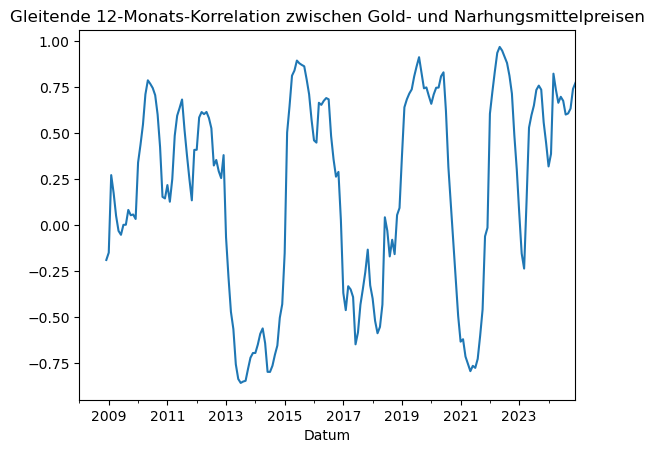

In [15]:
# 4 - Algorithm
    # 3 - "Korrelation"

correlation, p_value = pearsonr(merged['Index_Gold'], merged['Index_Food'])
print(f'Pearson Korrelation: {correlation}, p-value: {p_value}')

if correlation > 0.5:
    print("Es gibt eine starke positive Korrelation zwischen Gold- und Narhungsmittelpreisen. Wenn Sie eine Erhöhung der Lebensmittelpreise erwarten, könnte dies eine gute Zeit sein, um in Gold zu investieren, da auch Goldpreise wahrscheinlich steigen werden.")
elif correlation < -0.5:
    print("Es gibt eine starke negative Korrelation zwischen Gold- und Narhungsmittelpreisen. Gold könnte als Absicherung gegen steigende Lebensmittelpreise dienen; wenn Lebensmittelpreise steigen, könnten Goldpreise fallen.")
else:
    print("Die Korrelation zwischen Gold- und Narhungsmittelpreisen ist schwach oder nicht signifikant. Gold könnte als eine unabhängige Investition betrachtet werden, die nicht stark von Narhungsmittelpreisen beeinflusst wird. Dies könnte eine gute Gelegenheit für Diversifikation sein.")

rolling_corr = merged['Index_Gold'].rolling(window=12).corr(merged['Index_Food'])
rolling_corr.plot(title='Gleitende 12-Monats-Korrelation zwischen Gold- und Narhungsmittelpreisen')
plt.xlabel('Datum')  
plt.show()



In [16]:
# 4 - Algorithm
    # 4 "Monats Index Vergleich zwischen Gold und Lebensmitteln"

# Month Column as shared value to compare for seasonality
gold['Month'] = gold.index.month
food['Month'] = food.index.month

# Berechnen Sie den durchschnittlichen Indexwert pro Monat
gold_monthly_avg = gold.groupby('Month')['Index'].mean()
food_monthly_avg = food.groupby('Month')['Index'].mean()


print("\nDurchschnittlicher Food Index pro Monat:")
print(food_monthly_avg)




Durchschnittlicher Food Index pro Monat:
Month
1     95.588235
2     96.288235
3     96.400000
4     96.770588
5     96.764706
6     96.711765
7     96.582353
8     96.376471
9     96.676471
10    96.935294
11    97.341176
12    97.911765
Name: Index, dtype: float64


Jährliche % Änderungen des Goldpreises:
Date
2008-12-31          NaN
2009-12-31    17.440692
2010-12-31    31.501804
2011-12-31    21.743189
2012-12-31    16.114790
2013-12-31   -16.405844
2014-12-31   -13.027866
2015-12-31    11.161574
2016-12-31     7.406215
2017-12-31    -0.952139
2018-12-31    -3.682238
2019-12-31    14.922307
2020-12-31    24.865422
2021-12-31    -1.168724
2022-12-31    11.561334
2023-12-31     5.405364
2024-12-31    21.825506
Freq: YE-DEC, Name: Price, dtype: float64


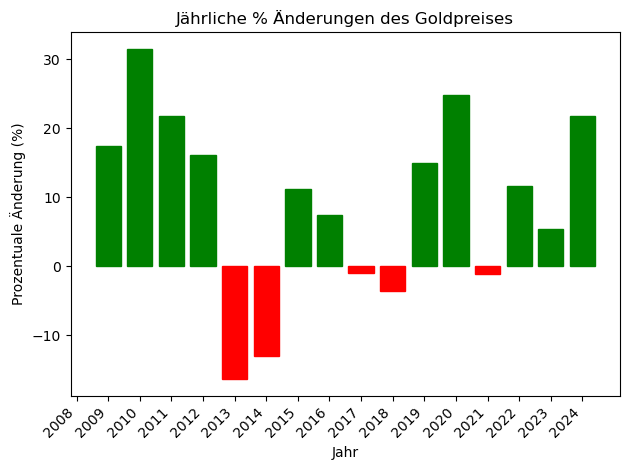

In [17]:
# 4 - Algorithm
    # 5 - "Jährliche % Änderungen des Goldpreises"

# Calculation of the annual average price
yearly_avg = gold['Price'].resample('YE').mean()

# Calculation of the annual percentage change
yearly_pct_change = yearly_avg.pct_change() * 100
yearly_pct_change.columns = ['Date', 'Percentage Change']

print("Jährliche % Änderungen des Goldpreises:")
print(yearly_pct_change)


bars = plt.bar(yearly_pct_change.index.year, yearly_pct_change.values)

# Setting colors based on the value of the change
for bar in bars:
    if bar.get_height() < 0:
        bar.set_color('red')
    else:
        bar.set_color('green')

plt.title('Jährliche % Änderungen des Goldpreises')
plt.xlabel('Jahr')
plt.ylabel('Prozentuale Änderung (%)')
plt.xticks(yearly_pct_change.index.year, rotation=45, ha='right')
plt.tight_layout()
plt.show()


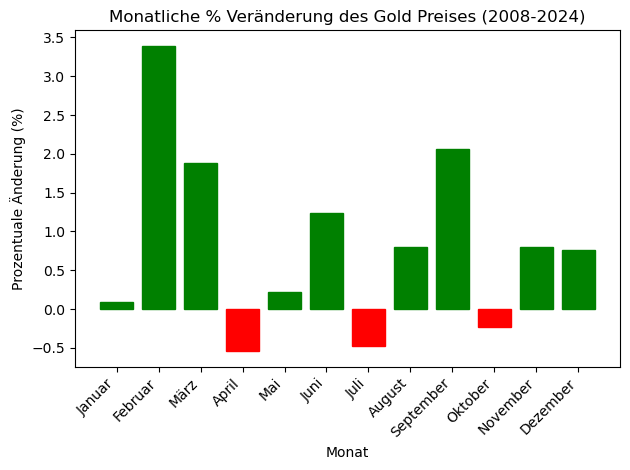

In [18]:
# 4 - Algorithm
    # 6 - "Monatliche % Veränderung des Gold Preises (2008-2024)"

# Calculation of monthly percentage change
monthly_pct_change = gold['Price'].resample('ME').mean().pct_change() * 100

# Adding a column for the month name and removing the date index
monthly_pct_change = monthly_pct_change.reset_index()
monthly_pct_change['Month'] = monthly_pct_change['Date'].dt.month_name(locale='de_DE.UTF-8')
monthly_pct_change = monthly_pct_change.set_index('Month')

# Grouping by month and calculating the average of percentage changes
avg_monthly_change = monthly_pct_change.groupby('Month')['Price'].mean()

# Sorting the months in the correct order by using the keys of month_dict
month_order = list(month_dict.keys())
avg_monthly_change = avg_monthly_change.reindex(month_order)

# Visualization of the average monthly percentage changes
bars = plt.bar(avg_monthly_change.index, avg_monthly_change.values)

# Setting colors based on the change value
for bar in bars:
    if bar.get_height() < 0:
        bar.set_color('red')
    else:
        bar.set_color('green')

plt.title('Monatliche % Veränderung des Gold Preises (2008-2024)')
plt.xlabel('Monat')
plt.ylabel('Prozentuale Änderung (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

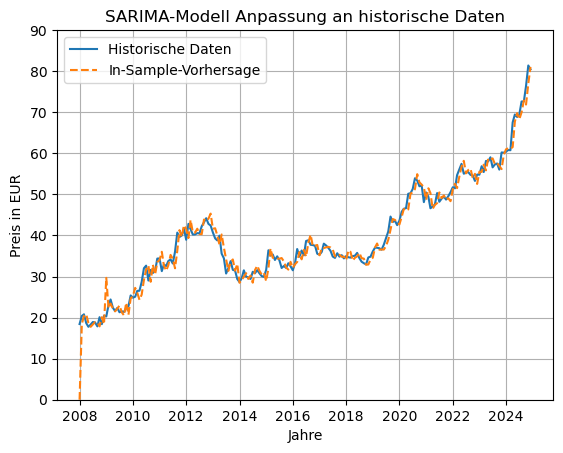

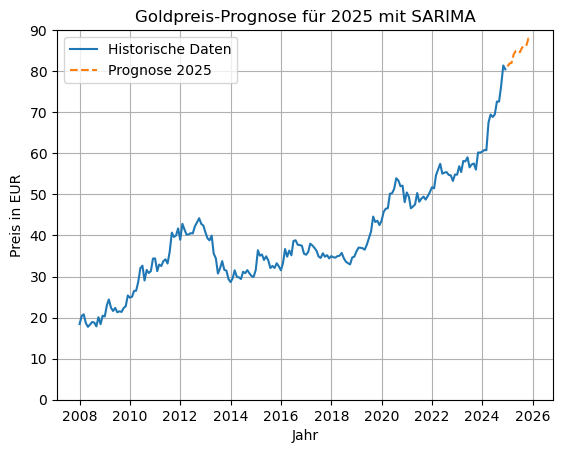

Prognosewerte für 2025:
January 2025: 81.17
February 2025: 81.89
March 2025: 82.03
April 2025: 84.08
May 2025: 84.92
June 2025: 85.04
July 2025: 84.63
August 2025: 85.77
September 2025: 86.05
October 2025: 86.14
November 2025: 87.97
December 2025: 87.63

 Kaufempfehlung: Es wird empfohlen, Gold zu kaufen, da der durchschnittliche prognostizierte Preis für 2025 über dem letzten bekannten Preis liegt.


In [19]:
# Prediciton

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Manual selection of ARIMA parameters 
gold = gold.asfreq('MS')  
order = (1,1,1)
seasonal_order = (1,1,1,12)

# Training the SARIMAX model
model = SARIMAX(gold['Price'], order=order, seasonal_order=seasonal_order)
model_fit = model.fit()

# In-sample forecast for evaluation
in_sample_forecast = model_fit.predict(start=gold.index[0], end=gold.index[-1])

# Plotting results
plt.plot(gold.index, gold['Price'], label='Historische Daten')
plt.plot(gold.index, in_sample_forecast, label='In-Sample-Vorhersage', linestyle='dashed')
plt.legend()
plt.title('SARIMA-Modell Anpassung an historische Daten')
plt.xlabel('Jahre')
plt.ylabel('Preis in EUR')
plt.ylim(0, 90) 
plt.grid()
plt.show()

# Forecast for 12 months (2025)
forecast = model_fit.forecast(steps=12)

# Plotting results
plt.plot(gold.index, gold['Price'], label='Historische Daten')
plt.plot(pd.date_range(gold.index[-1], periods=13, freq='MS')[1:], forecast, label='Prognose 2025', linestyle='dashed')
plt.legend()
plt.title('Goldpreis-Prognose für 2025 mit SARIMA')
plt.xlabel('Jahr')
plt.ylabel('Preis in EUR')
plt.ylim(0, 90) 
plt.grid()
plt.show()

# Display forecast values
print('Prognosewerte für 2025:')
for date, price in zip(pd.date_range(gold.index[-1], periods=13, freq='MS')[1:], forecast):
    print(f"{date.strftime('%B %Y')}: {price:.2f}")

# Purchase recommendation based on the forecast
last_known_price = gold['Price'].iloc[-1]
average_forecast_2025 = forecast.mean()

if average_forecast_2025 > last_known_price:
    recommendation = 'Kaufempfehlung: Es wird empfohlen, Gold zu kaufen, da der durchschnittliche prognostizierte Preis für 2025 über dem letzten bekannten Preis liegt.'
else:
    recommendation = 'Kaufempfehlung: Es wird nicht empfohlen, Gold zu kaufen, da der durchschnittliche prognostizierte Preis für 2025 unter dem letzten bekannten Preis liegt.'

print('\n', recommendation)